# Gradient Analysis

---

## Part 1:

**Question 1: The Reusability Advantage**

Consider a simple MLP: $\mathbf{p} = W\mathbf{x}$, $\mathbf{q} = \phi(\mathbf{p})$, $s = \mathbf{u}^T \mathbf{q}$, $o = \phi(s)$, $L = (o - y)^2$.

When computing $\frac{\partial L}{\partial w_{11}}$ via the chain rule, we get:

$$\frac{\partial L}{\partial w_{11}} = \frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s} \cdot \frac{\partial s}{\partial q_1} \cdot \frac{\partial q_1}{\partial p_1} \cdot \frac{\partial p_1}{\partial w_{11}}$$

Why is computing gradients **backward** (from $L$ toward $\mathbf{x}$) more efficient than computing each weight's gradient independently from scratch?

A) Because backward computation uses smaller numbers, avoiding numerical overflow  
B) Because intermediate terms like $\frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s}$ are shared across multiple weight gradients and only need to be computed once  
C) Because the chain rule only works in the backward direction  
D) Because backward computation avoids the need for activation function derivatives  

#### Answer:
B) Because intermediate terms like $\frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s}$ are shared across multiple weight gradients and only need to be computed once

explaination : when computing gradients for multiple weights, many of the intermediate terms in the chain rule are shared. For example $\frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s}$ is common to all weights that influence $s$. By computing these shared terms once and reusing them, we can significantly reduce the number of computations required making backward gradient computation much more efficient than computing each weight's gradient independently from scratch.

**Question 2: Zero and Equal Initialization**

Consider a fully connected neural network with multiple hidden layers, each having more than one neuron, and using a symmetric activation function such as $\tanh$.

Which of the following statements is **true** about weight initialization?

A) Initializing all weights to zero is fine because the gradients will break symmetry after the first update  
B) Initializing all weights to the same non-zero constant is fine because different inputs will produce different gradients  
C) Both zero initialization and equal-constant initialization cause all neurons in a layer to compute identical outputs and receive identical gradient updates, so symmetry is never broken  
D) Zero initialization causes vanishing gradients, but equal-constant initialization does not  

#### Answer:

C) Both zero initialization and equal-constant initialization cause all neurons in a layer to compute identical outputs and receive identical gradient updates, so symmetry is never broken

explaination : When all weights are initialized to zero or the same constant every neuron in the layer will produce the same output for any given input. As a result during backpropagtion all neurons will receive the same gradient updates. This means that all neurons will continue to compute the same outputs and receive the same updates in subsequent iterations, preventing the network from learning effectively as it cannot break symmetry and differentiate between neurons.

---

## Part 2: The Arithmetic of Gradients

**Question 3: Manual Gradient Computation**

**Scenario:**

Consider the following tiny MLP with **sigmoid** activation $\sigma(z) = \frac{1}{1 + e^{-z}}$ and MSE loss $L = (o - y)^2$:

$$p_1 = w_{11} x_1 + w_{12} x_2$$
$$q_1 = \sigma(p_1)$$
$$o = u_1 \cdot q_1$$
$$L = (o - y)^2$$

Given:  
- $x_1 = 1,\; x_2 = 2$  
- $w_{11} = 0.5,\; w_{12} = -0.5$  
- $u_1 = 1.0$  
- $y = 1$  

**Recall:** $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

**Task:**

1. Compute the forward pass: $p_1$, $q_1$, $o$, and $L$.  
2. Compute $\frac{\partial L}{\partial u_1}$ and $\frac{\partial L}{\partial w_{11}}$ using the chain rule.

*Show your steps below.*

#### Your Solution:

1. **Forward Pass:**
 $p_1 = w_{11} x_1 + w_{12} x_2 = 0.5 \cdot 1 + (-0.5) \cdot 2 = 0.5 - 1 = -0.5$
 $q_1 = \sigma(p_1) = \sigma(-0.5) = \frac {1}{1 + e^{0.5}} \approx 0.3775$
 $o = u_1 \cdot q_1 = 1.0 \cdot 0.3775 = 0.3775$
 $L = (o - y)^2 = (0.3775 - 1)^2 = (-0.6225)^2 \approx 0.3875$

2. **Backward Pass:**
 $\frac{\partial L}{\partial o} = 2(o - y) =   
2(0.3775 - 1) = 2(-0.6225) = -1.245$
 $\frac{\partial o}{\partial u_1} = q_1 = 0.3775$
 $\frac{\partial L}{\partial u_1} = \frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial u_1} = -1.245 \cdot 0.3775 \approx -0.4695$
 $\frac{\partial o}{\partial q_1} = u_1 = 1.0$
 $\frac{\partial q_1}{\partial p_1} = \sigma'(p_1) = \sigma(-0.5)(1 - \sigma(-0.5)) = 0.3775 \cdot (1 - 0.3775) \approx 0.2350$
 $\frac{\partial p_1}{\partial w_{11}} = x_1 = 1$
 $\frac{\partial L}{\partial w_{11}} = \frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial q_1} \cdot \frac{\partial q_1}{\partial p_1} \cdot \frac{\partial p_1}{\partial w_{11}} = -1.245 \cdot 1.0 \cdot 0.2350 \cdot 1 \approx -0.2926$ 
 






**Question 4: Vanishing Gradient Intuition**

**Scenario:**

A network has $D$ layers, each applying: $h^{(l)} = \sigma(W^{(l)} h^{(l-1)})$.

The gradient of the loss w.r.t. a weight in layer $l$ involves a product of $D - l$ terms of the form $\sigma'(\cdot) \cdot W^{(\cdot)}$.

The maximum value of $\sigma'(z)$ for the sigmoid function is $0.25$ (at $z = 0$).

**Task:**

If $D = 10$ and you are computing the gradient for layer $l = 1$ (the first layer), you need to multiply through $9$ such terms. Assuming each $\sigma'(\cdot) = 0.25$ and each $|w| = 1$:

1. What is the magnitude of the gradient scaling factor at layer 1?  
2. Explain in one sentence why this is problematic for training deep networks with sigmoid activations.

#### Your Solution:

1. The magnitude of the gradient scaling factor at layer 1 is 
                                      (0.25)^9 ≈ 3.8×10^-6

2. This is problematic because the gradient becomes extremely small (vanishes) as it is backpropagated through many layers making it difficult for the network to learn and update weights effectively in the earlier layers.


---

## Part 3: Coding Challenge

In this section, you will implement the **forward pass** and **backward pass (backpropagation)** for a simple 2-layer MLP from scratch using only NumPy.

The network architecture is:

$$\mathbf{p} = W_1 \mathbf{x}$$
$$\mathbf{q} = \sigma(\mathbf{p})$$
$$s = \mathbf{w}_2^T \mathbf{q}$$
$$o = \sigma(s)$$
$$L = (o - y)^2$$

where $\sigma$ is the sigmoid activation.

**You are required to:**  
**A) Fill in `forward_pass`** — compute all intermediate values and the loss  
**B) Fill in `backward_pass`** — compute gradients of the loss w.r.t. all weights using the chain rule

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# ----- Activation function -----
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [3]:
# ----- Generate synthetic data (XOR-like problem) -----
# 4 samples, 2 features each
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

# XOR labels
Y = np.array([0, 1, 1, 0], dtype=float)

print("Dataset (XOR):")
for i in range(len(X)):
    print(f"  x = {X[i]}  ->  y = {Y[i]}")

Dataset (XOR):
  x = [0. 0.]  ->  y = 0.0
  x = [0. 1.]  ->  y = 1.0
  x = [1. 0.]  ->  y = 1.0
  x = [1. 1.]  ->  y = 0.0


In [4]:
# ----- Network parameters -----
# Layer 1: W1 is (hidden_dim x input_dim), b1 is (hidden_dim,)
# Layer 2: w2 is (hidden_dim,), b2 is scalar

hidden_dim = 4
input_dim = 2

W1 = np.random.randn(hidden_dim, input_dim) * 0.5
b1 = np.zeros(hidden_dim)
w2 = np.random.randn(hidden_dim) * 0.5
b2 = 0.0

print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"w2 shape: {w2.shape}")
print(f"b2: {b2}")

W1 shape: (4, 2)
b1 shape: (4,)
w2 shape: (4,)
b2: 0.0


In [5]:
def forward_pass(x, y, W1, b1, w2, b2):
    """
    Compute the forward pass for a single sample.
    
    Network:
        p = W1 @ x + b1          (pre-activation, hidden layer)
        q = sigmoid(p)            (post-activation, hidden layer)
        s = w2 @ q + b2           (pre-activation, output)
        o = sigmoid(s)            (output prediction)
        L = (o - y)^2             (MSE loss for one sample)
    
    Args:
        x: input vector, shape (input_dim,)
        y: scalar target label
        W1: weight matrix, shape (hidden_dim, input_dim)
        b1: bias vector, shape (hidden_dim,)
        w2: weight vector, shape (hidden_dim,)
        b2: scalar bias
    
    Returns:
        cache: dict with keys 'x', 'y', 'p', 'q', 's', 'o', 'L'
    """
    # TODO: Implement the forward pass
    # Step 1: Compute p = W1 @ x + b1
    # Step 2: Compute q = sigmoid(p)
    # Step 3: Compute s = w2 @ q + b2  (dot product)
    # Step 4: Compute o = sigmoid(s)
    # Step 5: Compute L = (o - y) ** 2
    # Return a dict with all intermediate values

    p = W1 @ x + b1
    q = sigmoid(p)
    s = w2 @ q + b2
    o = sigmoid(s)
    L = (o - y) ** 2
    cache = {
        'x': x,
        'y': y,
        'p': p,
        'q': q,
        's': s,
        'o': o,
        'L': L
    }
    return cache

In [6]:
def backward_pass(cache, W1, b1, w2, b2):
    """
    Compute gradients of L w.r.t. all parameters using backpropagation.
    
    Use the chain rule, propagating gradients backward:
        dL/do = 2(o - y)
        dL/ds = dL/do * sigmoid'(s)
        dL/dw2 = dL/ds * q           (since s = w2 @ q + b2)
        dL/db2 = dL/ds
        dL/dq = dL/ds * w2
        dL/dp = dL/dq * sigmoid'(p)   (element-wise)
        dL/dW1 = outer(dL/dp, x)      (since p = W1 @ x + b1)
        dL/db1 = dL/dp
    
    Args:
        cache: dict from forward_pass with 'x', 'y', 'p', 'q', 's', 'o', 'L'
        W1, b1, w2, b2: current network parameters
    
    Returns:
        grads: dict with keys 'dW1', 'db1', 'dw2', 'db2'
    """
    # TODO: Implement the backward pass using the chain rule
    # Step 1: dL_do = 2 * (o - y)
    # Step 2: dL_ds = dL_do * sigmoid_derivative(s)
    # Step 3: dL_dw2 = dL_ds * q
    # Step 4: dL_db2 = dL_ds
    # Step 5: dL_dq = dL_ds * w2
    # Step 6: dL_dp = dL_dq * sigmoid_derivative(p)   (element-wise)
    # Step 7: dL_dW1 = np.outer(dL_dp, x)
    # Step 8: dL_db1 = dL_dp
    # Return a dict with all gradients
    
    o = cache['o']
    y = cache['y']
    s = cache['s']
    q = cache['q']
    p = cache['p']
    x = cache['x']  

    dL_do = 2 * (o - y)
    dL_ds = dL_do * sigmoid_derivative(s)
    dL_dw2 = dL_ds * q
    dL_db2 = dL_ds
    dL_dq = dL_ds * w2
    dL_dp = dL_dq * sigmoid_derivative(p)
    dL_dW1 = np.outer(dL_dp, x)
    dL_db1 = dL_dp  
    grads = {
        'dW1': dL_dW1,
        'db1': dL_db1,
        'dw2': dL_dw2,
        'db2': dL_db2
    }
    return grads


In [7]:
# ----- Training loop -----
lr = 1.0
epochs = 5000
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    dW1_acc = np.zeros_like(W1)
    db1_acc = np.zeros_like(b1)
    dw2_acc = np.zeros_like(w2)
    db2_acc = 0.0
    
    for i in range(len(X)):
        # Forward
        cache = forward_pass(X[i], Y[i], W1, b1, w2, b2)
        total_loss += cache['L']
        
        # Backward
        grads = backward_pass(cache, W1, b1, w2, b2)
        dW1_acc += grads['dW1']
        db1_acc += grads['db1']
        dw2_acc += grads['dw2']
        db2_acc += grads['db2']
    
    # Average gradients over batch
    N = len(X)
    W1 -= lr * dW1_acc / N
    b1 -= lr * db1_acc / N
    w2 -= lr * dw2_acc / N
    b2 -= lr * db2_acc / N
    
    avg_loss = total_loss / N
    loss_history.append(avg_loss)
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {avg_loss:.6f}")

Epoch     0 | Loss: 0.252779
Epoch   500 | Loss: 0.207992
Epoch  1000 | Loss: 0.023761
Epoch  1500 | Loss: 0.005800
Epoch  2000 | Loss: 0.002973
Epoch  2500 | Loss: 0.001939
Epoch  3000 | Loss: 0.001419
Epoch  3500 | Loss: 0.001111
Epoch  4000 | Loss: 0.000909
Epoch  4500 | Loss: 0.000767


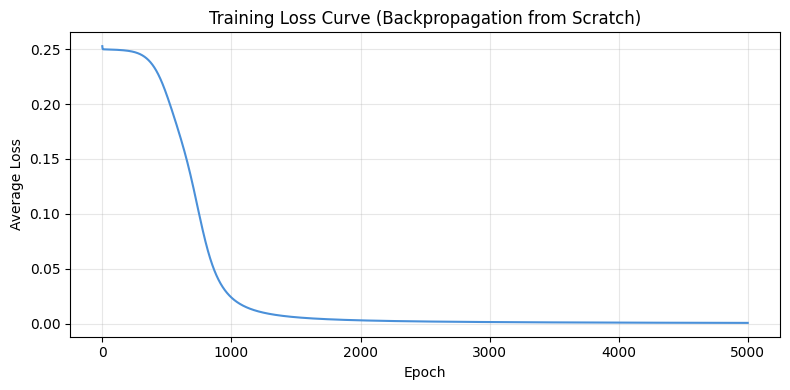

In [8]:
# ----- Plot training loss -----
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#4A90D9', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Curve (Backpropagation from Scratch)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ----- Evaluate predictions -----
print("\nFinal Predictions:")
print("-" * 40)
for i in range(len(X)):
    cache = forward_pass(X[i], Y[i], W1, b1, w2, b2)
    pred = cache['o']
    print(f"  x = {X[i]}  |  y = {Y[i]:.0f}  |  pred = {pred:.4f}  |  rounded = {round(pred)}")

print("\nIf your forward and backward passes are correct,")
print("the predictions should closely match the XOR labels.")


Final Predictions:
----------------------------------------
  x = [0. 0.]  |  y = 0  |  pred = 0.0293  |  rounded = 0
  x = [0. 1.]  |  y = 1  |  pred = 0.9754  |  rounded = 1
  x = [1. 0.]  |  y = 1  |  pred = 0.9759  |  rounded = 1
  x = [1. 1.]  |  y = 0  |  pred = 0.0245  |  rounded = 0

If your forward and backward passes are correct,
the predictions should closely match the XOR labels.


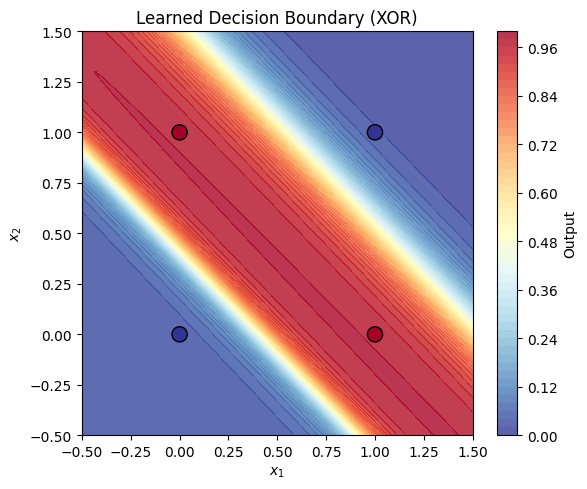

In [10]:
# ----- Visualize the learned decision boundary -----
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = []
for pt in grid:
    cache = forward_pass(pt, 0, W1, b1, w2, b2)
    Z.append(cache['o'])
Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(label='Output')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='RdYlBu_r', edgecolors='k', s=120, zorder=5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Learned Decision Boundary (XOR)')
plt.tight_layout()
plt.show()